In [18]:
#Title: Orbit Prediction with Noisy Measurements Using an Extended Kalman Filter

#Background:
    #When predicting orbits, measurements from telescopes and sensors are noisy, 
    #so the observed position is not exactly the true position. 
    #This project explores how a physics-based model combines with filtering can recover
    #the true trajectory more accurately than raw measurements alone

#Equations
    #x=[x, y, dx/dt, dy/dt]^T 
    #Look at the report for more info...

In [ ]:
#Table of contents:
#Cell 3: Simulate the real orbit
#Cell 4: Pretend measurements are noisy
#Cell 5: use ekf to recover the hidden true state
#Cell 6-8: compare truth, noisy data, and ekf estimate
#cell 9: use ekf estimate to predict future motion

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import inv

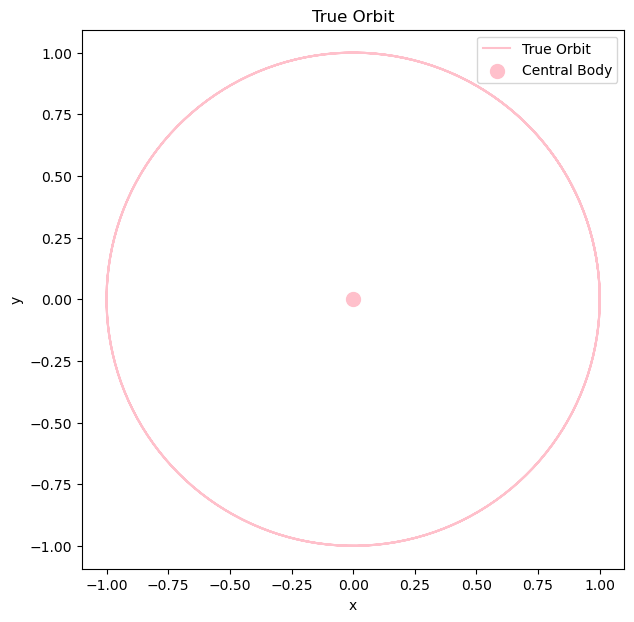

In [6]:
#Define the true physics model, simulate the true orbit, and plot it

#fixing a random seed so you get the same noisy data every time
np.random.seed(42)
#set a default figure size for plots
plt.rcParams["figure.figsize"] = (7, 7)


#Defining the physics (the differential equations for motion under gravity in 2D).
    #position changes according to velocity, and velocity according to gravitational accel.
#using a 2D gravitational model bc 3D would be too complicated
mu = 1.0 #the gravitational parameter
def orbit_dynamics(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    ax = -mu * x / r**3
    ay = -mu * y / r**3
    return [vx, vy, ax, ay]


#Initial conditions (position and velocity)
initial_state = [1.0, 0.0, 0.0, 1.0]   # [x, y, vx, vy]
t_start = 0
t_end = 20 #simulate from time 0 to 20
num_points = 1000 #eval the solutation at 1000 time points
t_eval = np.linspace(t_start, t_end, num_points)


#Simulate true orbit: (numerically solves the differential equations from orbit_dynamics)
solution = solve_ivp( 
    orbit_dynamics,
    (t_start, t_end),
    initial_state,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

#store true positions and velocity over time
x_true = solution.y[0]
y_true = solution.y[1]
vx_true = solution.y[2]
vy_true = solution.y[3]


#Plot the true orbit (ideal orbit with no measurement noise)
plt.figure()
plt.plot(x_true, y_true, label="True Orbit", color = "pink")
plt.scatter([0], [0], s=100, label="Central Body", color = "pink")
plt.xlabel("x")
plt.ylabel("y")
plt.title("True Orbit")
plt.axis("equal")
plt.legend()
plt.show()

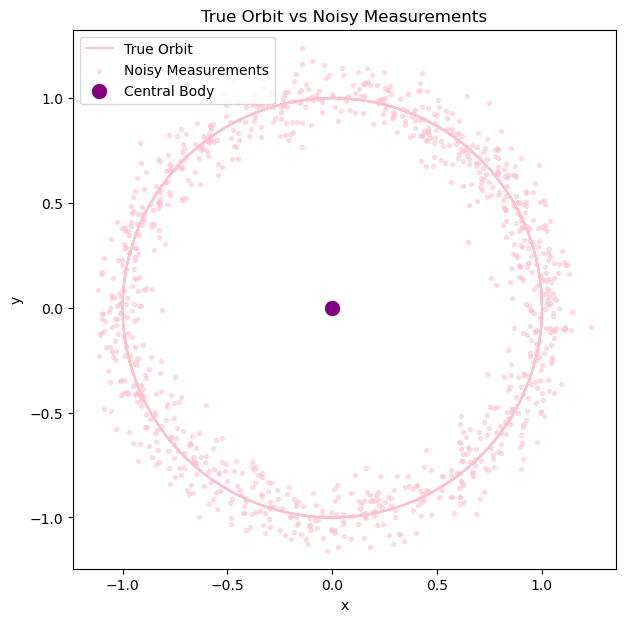

In [19]:
#Generate noisy measurements (simulate what noisy sensor data would look like):

#Real sensors don't give exact positions, so add Gaussian noise to the 
#true x and y positions. 
    #Basically pretend your sensor is imperfect. 
    #Measured x and y are the true values plus random Gaussian noise. 
#Guassian noise: draws random numbers from a normal dist with mean 0 & stdev sigma
sigma = 0.08  # noise strength

x_meas = x_true + np.random.normal(0, sigma, size=len(x_true))
y_meas = y_true + np.random.normal(0, sigma, size=len(y_true))

#make a 2 column array where each row is one measured position:
measurements = np.vstack((x_meas, y_meas)).T

#Plot true orbit and noisy measurements
plt.figure()
plt.plot(x_true, y_true, label="True Orbit", color = "pink")
plt.scatter(x_meas, y_meas, s=8, alpha=0.5, label="Noisy Measurements", color = "pink")
plt.scatter([0], [0], s=100, label="Central Body", color = "purple")
plt.xlabel("x")
plt.ylabel("y")
plt.title("True Orbit vs Noisy Measurements")
plt.axis("equal")
plt.legend(loc = 'upper left')
plt.show()

In [8]:
#Main ekf (extended kalman filter) cell
    #Estimate the hidden true orbit from noisy position measurements
    #random note: extended kalman filter = nonlinear version of kalman filter

#Compute the time step between measurements:
dt = t_eval[1] - t_eval[0]

#state transition function: predict the next state from the current state using a small euler step
    #takes position & vel. computes gravity and updates position and velocity forward by one 
    #time step. 
    #This is the EKF's prediction model
def f(state, dt, mu=1.0):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    ax = -mu * x / r**3
    ay = -mu * y / r**3

    x_new = x + vx * dt
    y_new = y + vy * dt
    vx_new = vx + ax * dt
    vy_new = vy + ay * dt

    return np.array([x_new, y_new, vx_new, vy_new])


#Compute the Jacobian matrix of the state transition. (This makes it ekf instead of kf)
    #The system is nonlinear. EKF needs a local linear approx. This matrix tells the filter how
    #small changes in the state affect the next predicted state.
def jacobian_F(state, dt, mu=1.0):
    x, y, vx, vy = state
    r2 = x**2 + y**2
    r = np.sqrt(r2)
    r5 = r2**(2.5)

    dax_dx = -mu * (1/r**3 - 3*x**2/r5)
    dax_dy =  3*mu * x*y / r5
    day_dx =  3*mu * x*y / r5
    day_dy = -mu * (1/r**3 - 3*y**2/r5)

    F = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [dt*dax_dx, dt*dax_dy, 1, 0],
        [dt*day_dx, dt*day_dy, 0, 1]
    ])

    return F


#Measurement model: measurement only sees position, not vel => z = [x, y]
def h(state):
    x, y, vx, vy = state
    return np.array([x, y])
#This matrix says measured quantity depends on x and y, not vx or vy. 
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])


#Set EKF parameters (noise and uncertainty settings):
# Process noise covariance
Q = np.diag([1e-6, 1e-6, 1e-5, 1e-5])
# Measurement noise covariance
R = np.diag([sigma**2, sigma**2])

# Initial estimate
x_est = np.array([x_meas[0], y_meas[0], 0.0, 0.8])
# Initial covariance
P = np.diag([0.1, 0.1, 0.1, 0.1])


#run the EKF loop
estimated_states = []

for z in measurements:
    # Predict
    F = jacobian_F(x_est, dt, mu)
    x_pred = f(x_est, dt, mu)
    P_pred = F @ P @ F.T + Q

    # Update
    y_residual = z - h(x_pred)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_est = x_pred + K @ y_residual
    P = (np.eye(4) - K @ H) @ P_pred

    estimated_states.append(x_est.copy())

estimated_states = np.array(estimated_states)

x_ekf = estimated_states[:, 0]
y_ekf = estimated_states[:, 1]
vx_ekf = estimated_states[:, 2]
vy_ekf = estimated_states[:, 3]

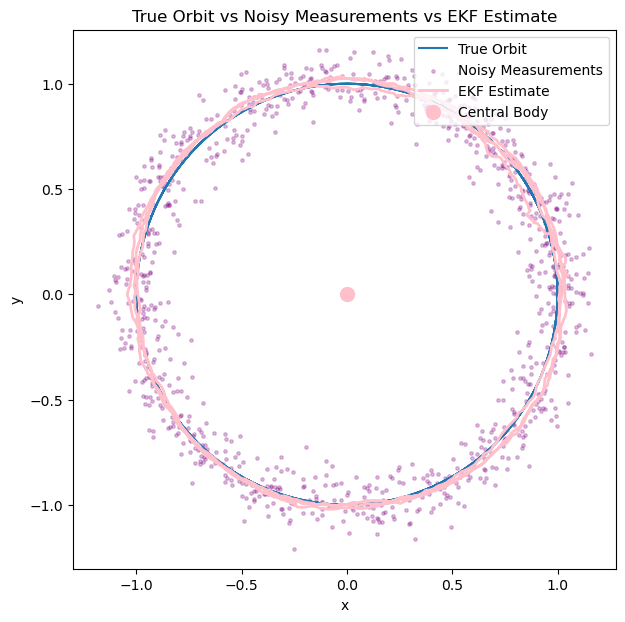

In [15]:
#plot true orbit, noisy measurements, and EKF estimate
    #shows that the ekf estimate tracks the true orbit better than noisy points!!
plt.figure()
plt.plot(x_true, y_true, label="True Orbit")
plt.scatter(x_meas, y_meas, s=6, alpha=0.25, label="Noisy Measurements", color = "purple")
plt.plot(x_ekf, y_ekf, linewidth=2, label="EKF Estimate", color = "pink")
plt.scatter([0], [0], s=100, label="Central Body", color = "pink")
plt.xlabel("x")
plt.ylabel("y")
plt.title("True Orbit vs Noisy Measurements vs EKF Estimate")
plt.axis("equal")
plt.legend(loc = "upper right")
plt.show()

In [10]:
#compute the position error at each step
#measurement erorr = distance between measured point and true point
measurement_error = np.sqrt((x_meas - x_true)**2 + (y_meas - y_true)**2)
#ekf error: distance between estimated point and true point
ekf_error = np.sqrt((x_ekf - x_true)**2 + (y_ekf - y_true)**2)

print("Average measurement error:", np.mean(measurement_error))
print("Average EKF error:", np.mean(ekf_error))

Average measurement error: 0.0986123267964656
Average EKF error: 0.02392799783046583


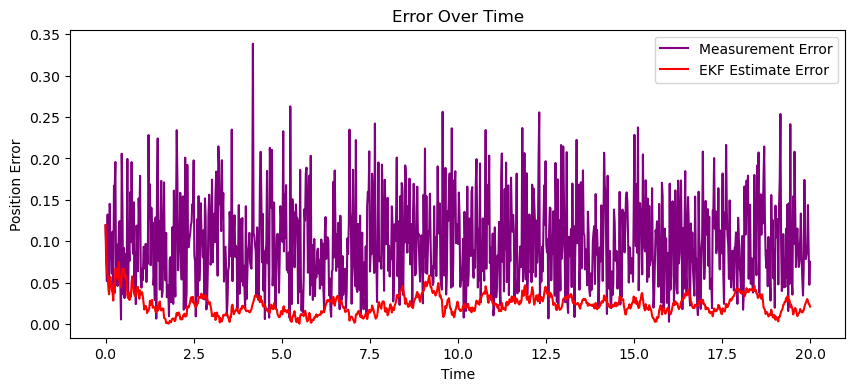

In [16]:
#plot error over time: shows the ekf's improvements  (obviously better)
plt.figure(figsize=(10, 4))
plt.plot(t_eval, measurement_error, label="Measurement Error", color = "purple")
plt.plot(t_eval, ekf_error, label="EKF Estimate Error", color = "red")
plt.xlabel("Time")
plt.ylabel("Position Error")
plt.title("Error Over Time")
plt.legend()
plt.show()

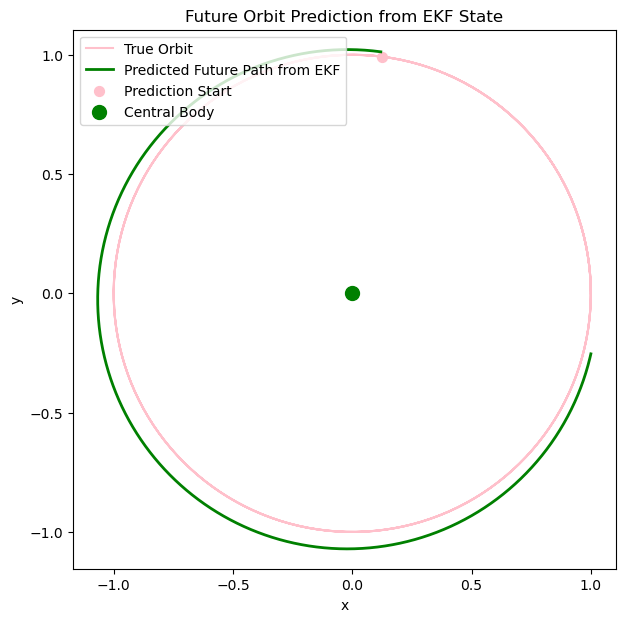

In [17]:
#predict future trajectory from the EKF estimate. E.g. 700. 
start_idx = 700
pred_initial_state = estimated_states[start_idx]
t_future = np.linspace(0, 5, 300)

#propafate forward. Use ekf estimate as a starting opint and runs physics model forward
future_solution = solve_ivp(
    orbit_dynamics,
    (0, 5),
    pred_initial_state,
    t_eval=t_future,
    rtol=1e-9,
    atol=1e-9
)

x_pred = future_solution.y[0]
y_pred = future_solution.y[1]

#plot future prediction
plt.figure()
plt.plot(x_true, y_true, label="True Orbit", color = "pink")
plt.plot(x_pred, y_pred, linewidth=2, label="Predicted Future Path from EKF", color = "green")
plt.scatter([x_true[start_idx]], [y_true[start_idx]], s=50, label="Prediction Start", color = "pink")
plt.scatter([0], [0], s=100, label="Central Body", color = "green")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Future Orbit Prediction from EKF State")
plt.axis("equal")
plt.legend(loc = "upper left")
plt.show()